In [1]:
from pathlib import Path
import sys

import numpy as np
import math,random,os,sys, importlib, time
ROOT = Path.cwd().resolve().parents[0]
SRC  = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.utils import plot_traj, check_safety
from data.utils import compute_x_safety_map, compute_mu_safety_map
from data.plotting import plot_x_safety_map, plot_mu_safety_map



(10000, 2)
Empirical safety probability: 0.9211
Chance constraint threshold (1-eta) = 0.9000 -> config_safety = 1


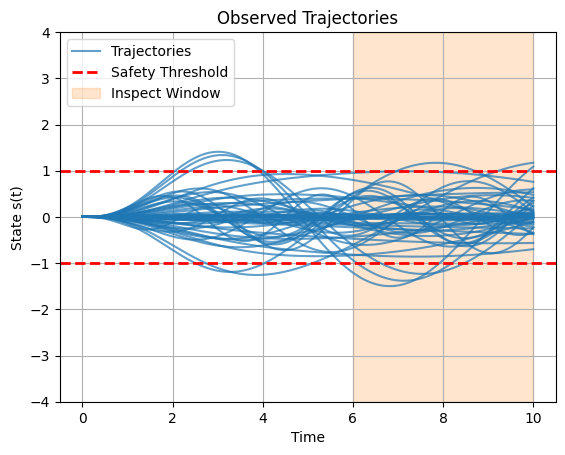

In [9]:

z_0 = np.array([0.0, 0.0])  # baseline configuration
params = SpringParams(mass=1.0, damping=1, stiffness=2.0) # system parameters

mean = np.array([0,0]); cov = np.diag([1, 1]) # parameters of the X distribution


tau = 1 # safety upper threshold for trajectory
T = 10; dt = 0.01 # t \in [0,T] with step dt = 0.01
time_window = (6, 10) # inspection window
seed = 1 # random seed


# X = sample_x(n_samples = 10000, dist_type="gaussian", params={"mean": mean, "cov": cov}, seed=seed)

#### a bounded box 
low, high = -3.0, 3.0
X = sample_x(n_samples = 10000, dist_type="gaussian", params={"mean": mean, "cov": cov}, seed=seed,truncate_box=(low,high))
print(X.shape)

###### return a dict with keys: dict_keys(['t', 's', 's_dot']), time (T array), position (n * T array), velocity (n * T array)
traj = simulate_spring(params, t_final=T, dt=dt, X=X, forcing_type='sin', config=z_0)

### in real data only observe X and traj['s], traj['s_dot]
# Check whether current configuration is safe under baseline N(mean, cov)
# safety_indicator = 1 if safe, 0 if unsafe
eta = 0.1
safety_indicator = check_safety(traj, threshold=tau, window=time_window)

p_safe = float(np.mean(safety_indicator))
print(f"Empirical safety probability: {p_safe:.4f}")

config_safety = 1 if p_safe >= 1.0 - eta else 0  # chance constraint
print(f"Chance constraint threshold (1-eta) = {1.0 - eta:.4f} -> config_safety = {config_safety}")
plot_traj(traj, threshold=tau, window=time_window,n_max=50,title='Observed Trajectories',ylim=(-4,4))


In [5]:
res = compute_mu_safety_map(params, t_final=T, dt=dt,
    window=time_window,
    threshold=tau,
    cov=cov,
    n_mu_grid=21,
    mu_limits= (-1.0, 1.0),
    n_per_mu = 6000,
    forcing_type="sin",
    config=z_0,
    eta = 0.1,
    truncate_X_box=(low,high),
    batch_size=2000,
    seed=0)

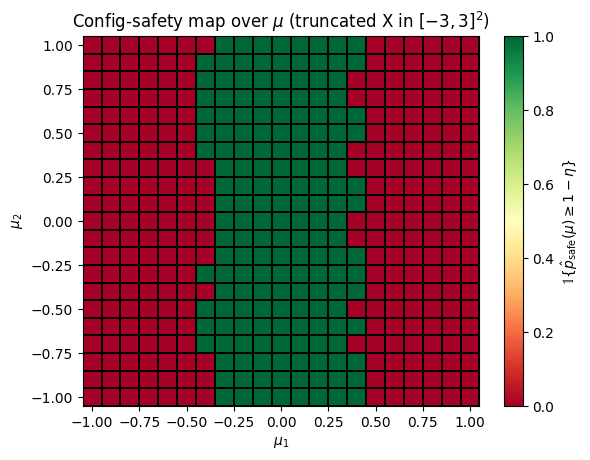

In [6]:
# Plot indicator (0/1 per mu cell) with visible cell boundaries
plot_mu_safety_map(
    res,
    mode="indicator",
    title=r"Config-safety map over $\mu$ (truncated X in $[-3,3]^2$)",
    cmap="RdYlGn",
    show_cell_edges=True,
    linewidth=0.1,
    draw_boundary=False,
)

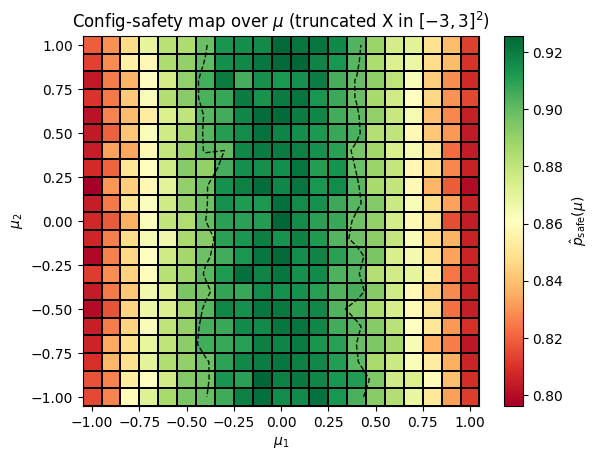

In [10]:
# Plot indicator (0/1 per mu cell) with visible cell boundaries
plot_mu_safety_map(
    res,
    mode="prob",
    title=r"Config-safety map over $\mu$ (truncated X in $[-3,3]^2$)",
    cmap="RdYlGn",
    show_cell_edges=True,
    linewidth=0.1,
    draw_boundary=True,
    vmax=res['safe'].max(),
    vmin=res['safe'].min(),
    eta=0.1
)

In [15]:

res_x_safety = compute_x_safety_map(params, t_final=T, dt=dt, window=time_window,
                           threshold=tau, n_grid=300, box_limits=(-3,3),
                           forcing_type="sin", config=z_0)


Empirical safety probability=0.8895 vs threshold 0.9000 (eta=0.1000) -> UNSAFE


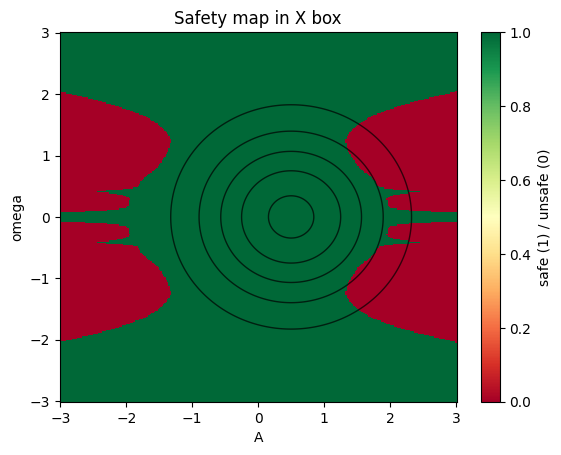

In [16]:
mean_test = np.array([0.5,0])
cov_test = np.diag([1, 1])
plot_x_safety_map(res_x_safety, mean=mean_test, cov=cov_test,
                  contour_levels=5, contour_color="black",
                  contour_alpha=0.7, eta=0.1, print_msg=True)
